<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">
  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExbDEyM3pnb2RtMnY5eXhvNTZvdzhsYTAyeTIzbHVsNHlyazY1NDVtciZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/tQS8W6vdhBZgA/giphy.gif" alt="Reinforced concrete design animation" width="500" style="max-width:100%; border-radius:10px;">
  <h3 style="color:#ffffff; margin:0 0 8px 0;"><b>Flexure II: Strength Design of Reinforced Concrete Beams</b></h3>
  <p style="margin:4px 0;"><b>Authors:</b> Msc. Ing. Carlos Andr&eacute;s Celi S&aacute;nchez &middot; Nicol&aacute;s Mora Bowen &middot; Juan Sebasti&aacute;n Baquero</p>
  <p style="margin:4px 0;"><b>Course:</b> Reinforced Concrete Design II</p>
  <p style="margin:4px 0; color:#d1d5db;">From compatible strains and internal forces to nominal strength and code design strength.</p>
  <img src="assets/authors.png" alt="Course authors" width="900" style="max-width:100%; margin-top:22px; border-radius:10px;">
</div>

## Sectional Strength Criteria

The structural model supplies the factored demand $M_u$. This notebook determines whether a section can provide the corresponding design strength. For a member governed by flexure, the basic requirement is:

$$\phi M_n \geq M_u$$

The inequality has three distinct meanings. $M_u$ is the required effect from factored loads and analysis. $M_n$ is the nominal resistance obtained from an internally equilibrated strain and stress state. $\phi M_n$ is the design strength accepted after accounting for uncertainty and, crucially, for the deformation character of the section. A high nominal moment is not automatically a desirable resistance if it is reached through a compression-controlled and brittle response.

For members with small axial load relative to $f'_cA_g$, flexural beam behavior is appropriate. When axial force becomes significant, the section must be treated through combined axial force and bending rather than by importing beam formulas outside their domain.

## Design Assumptions

Strength design retains the compatibility principles developed in Flexure I: plane sections remain plane, strain is compatible between concrete and bonded reinforcement, and internal forces satisfy equilibrium. At nominal strength, the extreme compression-fibre strain is taken as $\varepsilon_{cu}=0.003$ under the ACI sectional model, and tensile concrete is neglected in flexural resistance after cracking.

These assumptions do not say that concrete has no tensile behavior at service or that its compression stress is rectangular in reality. They define a calibrated design representation at a specified limit state. The physical stress-strain response remains nonlinear; the design model must reproduce the resistance and resultant location with sufficient reliability for code design.

### Equivalent Whitney Compression Block

The Whitney block is not the actual stress distribution in concrete. Before introducing it, begin with the physical compression field. At nominal strength, plane sections produce a linear strain field from $\varepsilon_{cu}$ at the extreme compression fibre to zero at the neutral axis $c$. A nonlinear concrete constitutive law converts that strain field into a nonuniform stress distribution $f_c(y)$. For a rectangular section of width $b$, its exact resultant and centroid would be:

$$C_{real}=b\int_0^c f_c(y)\,dy, \qquad y_{real}=\frac{b\int_0^c y f_c(y)\,dy}{C_{real}}$$

The first integral gives the magnitude of compression; the second gives where that compression acts. Both are needed because flexural resistance is an internal couple, not a force alone. A parabolic Hognestad-type curve, for example, can describe the ascending concrete response and a descending branch after its peak. Such a model is appropriate when studying moment-curvature, stiffness, and post-peak response.

The design problem is different. Rather than integrate a material law for every section, ACI permits a calibrated rectangular substitute that reproduces the resultant and its practical lever arm with adequate reliability at nominal strength. For a rectangular compression zone, the Whitney model takes a uniform stress $0.85f'_c$ over an equivalent depth $a$:

$$a=\beta_1c, \qquad C_c=0.85f'_cba, \qquad y_C=\frac{a}{2}$$

The word *equivalent* is doing the real work. The block does not claim that concrete stress is uniformly $0.85f'_c$ from the surface to $a$, nor that concrete suddenly stops carrying stress at $a$. It gives a force $C_c$ and a centroid $a/2$ intended to stand in for $C_{real}$ and $y_{real}$ in a strength calculation. The coefficient $\beta_1$ changes with the specified concrete strength because the shape and concentration of the actual compression field change; $a$ is consequently a modelling depth, while $c$ remains the physical neutral-axis depth dictated by compatibility.

Compatibility is never bypassed. Once $c$ is known, steel strain follows from similar triangles:

$$\varepsilon_s=0.003\frac{d-c}{c}$$

The steel constitutive law then supplies $f_s$. For a singly reinforced section with yielding steel, $T=A_sf_y$ and equilibrium requires $C_c=T$. The internal moment is obtained from the distance between the two resultants, not memorized independently:

$$M_n=C_c\left(d-\frac{a}{2}\right)=T\left(d-\frac{a}{2}\right)$$

This is the boundary of the model. The Whitney block is a nominal-strength representation; it does not predict cracking, cracked stiffness, deflection, tension stiffening, curvature before yield, concrete softening, confinement effects, or cyclic deterioration. Those are response questions and require the material-level treatment developed in Flexure I.

<div style="display:flex; flex-wrap:wrap; gap:20px; justify-content:center; margin:28px 0;"><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-12.png" alt="Nominal-strain assumption" width="650" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-13.png" alt="Concrete compression model" width="340" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-14.png" alt="Equivalent concrete stress block" width="700" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-15.png" alt="Whitney-block parameters" width="850" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-16.png" alt="Steel constitutive idealization" width="500" style="max-width:100%;"></figure></div>

## Calculation of the Strength Reduction Factor, $\phi$

The factor $\phi$ follows the net tensile strain $\varepsilon_t$ at nominal strength; it is not selected from the reinforcement ratio. For the tension layer furthest from the compression face, compatibility gives:

$$\varepsilon_t = 0.003\frac{d_t-c}{c}$$

The applicable ACI table classifies the section as compression-controlled, transition, or tension-controlled. The transition factor is obtained by interpolation from strain, not from a guessed label. This gives code form to the ductility sequence developed in Flexure I: shallow $\varepsilon_t$ means limited deformation warning; large $\varepsilon_t$ means the steel has developed a reliably ductile tensile response.

The design-strength calculation is completed only after $M_n$ and $\varepsilon_t$ are found from the same compatible state. It is therefore incorrect to calculate a nominal moment with one assumed neutral axis and assign $\phi$ using a different one.

For ordinary nonprestressed flexural members, define the yield strain as $\varepsilon_y=f_y/E_s$. The tension-controlled boundary is expressed as $\varepsilon_t\geq\varepsilon_y+0.003$, while the compression-controlled boundary occurs at $\varepsilon_t\leq\varepsilon_y$. Between them, the applicable code interpolates $\phi$ linearly. The interpolation is not arbitrary: it reduces the design claim as the available tensile deformation margin disappears. Thus $\phi$ embeds both model uncertainty and the reliability of the failure sequence.

## Minimum Reinforcement

Minimum flexural reinforcement is a post-cracking requirement. At first cracking, tensile force transfers rapidly from concrete to steel; the minimum area ensures that the member can continue resisting moment after this transfer instead of losing capacity abruptly.

The applicable ACI expression for $A_{s,\min}$ must be evaluated using its stated code edition and unit system. Its physical objective is not to prescribe an arbitrary bar count: it requires post-cracking nominal capacity to exceed the cracking condition by an appropriate margin. The cracking reference is $M_{cr}=f_rI_g/y_t$; the selected reinforcement must make the post-cracking section capable of carrying moment beyond that event. The check applies at every location where analysis requires tensile reinforcement.

Minimum reinforcement is not waived by obtaining a small calculated $A_s$ from flexural demand; that is precisely the condition it is intended to govern. To see the mechanics, compare the pre-cracking estimate $M_{cr}=f_rI_g/y_t$ with the post-cracking couple $M_n\approx A_sf_s z$. If $A_s$ is insufficient, the flexural resistance immediately after the first crack can be lower than the moment that created the crack. The minimum-steel provisions prevent this negative capacity jump.

<div style="display:flex; flex-wrap:wrap; gap:24px; justify-content:center; align-items:flex-start; margin:28px 0;">
  <figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-17.png" alt="Strength-reduction classification table" width="1000" style="max-width:100%; border-radius:8px;"><figcaption style="margin-top:10px; color:#475569; font-size:0.9em;">Figure. The factor follows code strain classification.</figcaption></figure>
  <figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-18.png" alt="Net tensile strain diagram" width="600" style="max-width:100%; border-radius:8px;"><figcaption style="margin-top:10px; color:#475569; font-size:0.9em;">Figure. Compatibility supplies the net tensile strain.</figcaption></figure>
</div>

## Minimum Reinforcement in T-Beams

For a T-beam, minimum tension reinforcement follows the member-web definition prescribed by the code, not automatically the full effective flange width. The flange may contribute to compression in positive bending, but it does not create a proportionate tension-reinforcement demand across its entire width.

This distinction prevents a deceptively low ratio from being created by using a very wide slab flange in a rule intended to secure the post-cracking behavior of the beam stem. The relevant geometric measure is therefore $\rho_w=A_s/(b_wd)$ when the code provision is expressed through the web. In positive bending the flange improves concrete compression capacity, but the tension force still enters through bars concentrated in the stem; the two mechanisms should not be mixed in a minimum-reinforcement check.

## Maximum Reinforcement

For beam-type members, the code ductility requirement limits the amount of tension reinforcement through the tensile-strain condition. At nominal strength, the tension steel closest to the extreme tension face must achieve the strain required for tension-controlled behavior.

Increasing $A_s$ moves the neutral axis deeper. That reduces $\varepsilon_t$ for the same $\varepsilon_{cu}$ and can shift the section toward compression-controlled response. For beam behavior, the design check is written directly as $\varepsilon_t\geq\varepsilon_y+0.003$ using the applicable ACI definition of net tensile strain. The maximum is therefore a compatibility limit, not merely a geometric percentage.

For a singly reinforced rectangular section with yielding steel, $c=A_sf_y/(0.85\beta_1f'_cb)$. Substitution into $\varepsilon_t=0.003(d-c)/c$ makes the dependency explicit: increasing $A_s$ increases $c$, reduces $\varepsilon_t$, and can violate the tension-controlled limit even while increasing $M_n$.

<div style="display:flex; flex-wrap:wrap; gap:20px; justify-content:center; margin:28px 0;"><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-19.png" alt="Net tensile strain in a beam section" width="610" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-20.png" alt="Strength factor limits" width="1000" style="max-width:100%;"></figure></div>

## Balanced Condition

The balanced state occurs when the concrete reaches $\varepsilon_{cu}$ at the same time that the extreme tension steel reaches $\varepsilon_y$. Similar triangles give:

$$c_{bal}=\frac{\varepsilon_{cu}}{\varepsilon_{cu}+\varepsilon_y}d$$

With yielding tension steel, equilibrium gives $A_{s,bal}f_y=0.85f'_cb\beta_1c_{bal}$, or $\rho_{bal}=0.85\beta_1(f'_c/f_y)[\varepsilon_{cu}/(\varepsilon_{cu}+\varepsilon_y)]$. This is a reference state for understanding the boundary between ductile and brittle response; it is not an ordinary design target.

The derivation reveals the causal chain. At balance, the strain diagram fixes $c_{bal}/d$ before any force equation is used. The Whitney block then fixes $a_{bal}=\beta_1c_{bal}$ and $C_{bal}=0.85f'_cba_{bal}$. Only after those geometric and concrete-response decisions does $T_{bal}=A_{s,bal}f_y$ supply the steel area. The ratio $\rho_{bal}$ therefore condenses compatibility, a concrete model, and equilibrium; it is not an empirical maximum.

For $\rho<\rho_{bal}$ the neutral axis is shallower and steel reaches yield first. For $\rho>\rho_{bal}$ the neutral axis is deeper and concrete reaches its compression limit first. The code tensile-strain requirement intentionally keeps ordinary beams away from the balanced boundary.

<figure style="margin:28px 0; text-align:center;"><img src="assets/03_flexural_strength/reference-21.png" alt="Balanced section with compatible strains and internal forces" width="1050" style="max-width:100%; border-radius:8px;"><figcaption style="margin-top:10px; color:#475569; font-size:0.9em;">Figure. Balanced strain condition.</figcaption></figure>

## Beams with Compression Reinforcement

Compression reinforcement may be needed when section depth is restricted, negative-moment detailing requires bars on both faces, long-term deformation must be moderated, or additional deformation capacity is desired. Its force is not automatically $A'_sf_y$: compatibility at depth $d'$ gives $\varepsilon'_s$, the steel model gives $f'_s$, and then $C_s=A'_sf'_s$.

Equilibrium is $C_c+C_s=T_s$ and moment is assembled from each resultant with its own lever arm. Compatibility gives $\varepsilon'_s=0.003(c-d')/c$ and the steel law gives $f'_s$; only then is $C_s=A'_sf'_s$ known. If $|\varepsilon'_s|<\varepsilon_y$, then $f'_s=E_s\varepsilon'_s$ rather than $f_y$. The nominal moment may be written about the tension steel as $M_n=C_c(d-a/2)+C_s(d-d')$. Treating compression steel as a fixed extra couple without checking $f'_s$ is a common error.

There are two distinct reasons to add $A'_s$. It can provide compression force when architectural depth limits the concrete block, and it can change the strain state by reducing the compression demand assigned to concrete. The second effect can preserve tensile strain in the lower steel and improve available curvature, provided transverse reinforcement, development, and bar spacing make the mechanism physically available.

<div style="display:flex; flex-wrap:wrap; gap:20px; justify-content:center; margin:28px 0;"><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-22.png" alt="Compression-reinforced beam behavior" width="780" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-23.png" alt="Compression reinforcement force system" width="950" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-24.png" alt="Compression-reinforcement design relationship" width="870" style="max-width:100%;"></figure></div>

## Stability Criteria for Beams

Compression reinforcement and longitudinal bars must remain laterally restrained by properly detailed transverse reinforcement. Under large curvature, cover can spall and compression bars can buckle if their unsupported length and confinement are inadequate. This is a member-stability mechanism that a sectional $M_n$ calculation cannot certify by itself.

The practical implication is direct: the assumed strain distribution must be supported by bar development, confinement, shear resistance, and a constructible cage. A useful conceptual check is that the compression-bar unsupported length is governed by the transverse-tie spacing; as curvature increases after cover spalling, unrestrained compression bars are susceptible to local instability before the sectional strain limit is reached.

The inequality $\phi M_n\geq M_u$ assumes that the calculated force couple can form and remain stable. It does not independently check bar buckling, crushing of poorly confined cover, shear failure, lap-splice slip, or anchorage failure. A sound design therefore reads the sectional state together with the detailing that makes that state sustainable. Strength without stability is not usable flexural resistance.

## Minimum Member Depth

Minimum-depth provisions are a serviceability screen based on member type, span condition, reinforcement grade, and code scope. They do not replace a deflection calculation where loading, long-term effects, cracking, continuity, or nonstandard geometry make the simplified limits inapplicable.

A larger depth improves both flexural lever arm and stiffness. In the elastic range, $\kappa=M/(EI)$ and deflection follows from integrating curvature, so the second moment of area has a disproportionate influence. For a simply supported member under a uniform load, the elastic reference $\Delta_{max}=5wL^4/(384EI)$ makes clear why span and stiffness control serviceability so strongly. Cracking changes the effective stiffness, but does not change that physical dependence. It also changes self-weight, architectural clearances, shear demand, reinforcement layout, and construction. The code limit is therefore a starting constraint, not an optimization result.

<figure style="margin:28px 0; text-align:center;"><img src="assets/03_flexural_strength/reference-25.png" alt="Minimum member-depth reference" width="520" style="max-width:100%; border-radius:8px;"><figcaption style="margin-top:10px; color:#475569; font-size:0.9em;">Figure. Minimum-depth provisions are serviceability screening criteria.</figcaption></figure>

## Sections with Flanges

A flange participates in compression only through an effective width justified by beam-slab geometry and the governing code. In positive bending, first determine whether $a$ remains within the flange thickness. If it does, the section behaves as a rectangular section of width $b_f$. If it does not, split the compression resultant into $C_f=0.85f'_c(b_f-b_w)h_f$ and $C_w=0.85f'_cb_w(a-h_f)$, then locate the centroid of $C_f+C_w$ before calculating the moment.

The composite centroid is obtained from $y_C=(C_fy_f+C_wy_w)/(C_f+C_w)$. The nominal moment then follows from $M_n=(C_f+C_w)(d-y_C)$ for the simple force system. Effective flange width is a participation limit, not an invitation to count the entire slab. Under negative moment, the slab is commonly in tension and the web controls compression geometry.

## Isolated T-Beams

For an isolated T-beam, the effective flange width is limited by the geometry that can actually deliver compression into the stem. Once $b_f$, flange thickness $h_f$, and web width $b_w$ are established, the calculation follows one of two paths. If $a\leq h_f$, use $b_f$ in $C_c=0.85f'_cb_fa$. If $a>h_f$, calculate separate flange and web compression forces, then take moments of those forces about the tension steel. Thus $M_n=C_f(d-y_f)+C_w(d-y_w)$, with $y_f$ and $y_w$ measured to each resultant.

<div style="display:flex; flex-wrap:wrap; gap:20px; justify-content:center; margin:28px 0;"><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-26.png" alt="Flanged beam geometry" width="700" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-27.png" alt="T-beam compression regions" width="700" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-28.png" alt="Effective flange-width criteria" width="900" style="max-width:100%;"></figure></div>

## T-Beams in Slab Systems

In a monolithic slab-beam system, the effective flange is controlled by tributary slab participation, beam spacing, span, and flange thickness as prescribed by code. The section is not simply the architectural slab width. The compression field spreads into the slab only over a limited effective width, and that width must be evaluated for the specific beam and bending region. Mathematically, the selected $b_f$ enters directly into $C_c=0.85f'_cb_fa$ only when $a\leq h_f$; beyond that condition, the web-and-flange decomposition is required.

<div style="display:flex; flex-wrap:wrap; gap:20px; justify-content:center; margin:28px 0;"><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-29.png" alt="T-beam in slab system" width="820" style="max-width:100%;"></figure><figure style="margin:0; text-align:center;"><img src="assets/03_flexural_strength/reference-30.png" alt="Effective flange dimensions in slab system" width="500" style="max-width:100%;"></figure></div>

## Detailing Criteria

The selected reinforcement must be placeable, developed, spliced where required, and continued through the moment region that demands it. A calculated $A_s$ is only an area; it becomes a tensile resultant when bars have sufficient development and anchorage. In mechanics, the bar force develops through bond, $T=\int_0^{l_d}\pi d_bu_b(x)\,dx$. Thus a cutoff may be made only after sufficient embedment remains to transfer the force that the moment diagram demands.

The moment diagram and the bar-detailing diagram must therefore agree. If $M_u(x)$ decreases away from a critical section, the required tensile force also decreases, but a bar cannot terminate at the theoretical point where its area is no longer needed; it must extend beyond that point to develop the remaining force and meet the governing cutoff rules. This is the mechanical link between analysis, flexural design, and reinforcement drawings. Cover, clear spacing, bar layers, stirrups, congestion, hooks, and construction tolerances are part of flexural design rather than a drafting afterthought.

## Calculation of Nominal Capacity

For every section, nominal capacity comes from the same compatible state: prescribe $\varepsilon_{cu}$, establish the linear strain diagram, calculate the strain and stress of each steel layer, assemble concrete and steel forces, solve axial equilibrium, and take moments of those forces. In general form, solve $R(c)=C_c(c)+\sum C_{s,i}(c)-\sum T_{s,j}(c)-N_u=0$. The Whitney block is a shortcut for the concrete resultant; it does not replace force equilibrium or strain compatibility.

A credible calculation reports $c$, $a$, each steel strain and stress, $C_c$, any $C_s$, $T_s$, $M_n$, $\varepsilon_t$, and $\phi$. A practical root-finding sequence brackets a plausible $c$, evaluates the sign of $R(c)$, narrows the interval, and stops only when the force residual is acceptably small in consistent units. Omitting intermediate state variables makes it impossible to audit the nominal capacity.

## Simply Reinforced Beam

In the classroom, the simply reinforced-beam example is solved by hand first. Here it will be solved in code using the same sequence: assume the tension steel yields, solve $0.85f'_cba=A_sf_y$, obtain $c=a/\beta_1$, verify $\varepsilon_s=0.003(d-c)/c\geq\varepsilon_y$, calculate $M_n=A_sf_y(d-a/2)$, determine $\varepsilon_t$ and $\phi$, and compare $\phi M_n$ with $M_u$. If the yield assumption fails, obtain $f_s$ from compatible strain and solve equilibrium again.



![alt text](image.png)

In [1]:
import numpy as np                                                    # Import numerical operations
import pandas as pd                                                   # Import tabular-data utilities
import matplotlib.pyplot as plt                                       # Import plotting functions
from matplotlib import cm, colors, patches                          # Import colormap, normalization, and patch tools

### Data
fc = 250                                                           # Concrete compressive strength [kg/cm2]
fy = 4200                                                          # Steel yield strength [kg/cm2]
ec = 0.003                                                         # Ultimate concrete strain


b = 30                                                             # Beam width [cm]
h = 50                                                             # Total beam depth [cm]
rec = 2.5                                                          # Reinforcement cover to steel centroid [cm]

diam = 2.5                                                         # Bar diameter [cm]
Mu = 38.25 * 1e5                                                   # Factored bending moment [kg-cm]
fiM = 0.9                                                          # Flexural strength-reduction factor

### Calculations
if fc <= 2800:                                                     # Evaluate the equivalent stress-block factor
    Beta = 0.85                                                     # Set the initial beta value
    if 2800 < fc <= 5500:                                           # Apply the strength-dependent reduction
        Beta = 0.85-(0.05*(fc-280)/70)                              # Calculate beta from concrete strength
    else:
        Beta = 0.65                                                 # Apply the minimum beta value

d = h -rec                                                         # Calculate the effective depth [cm]

As = 0.85 * fc * b / fy * (d - np.sqrt(d**(2) - (2*Mu / fiM)/(0.85*fc*b)))  # Calculate required tensile steel area [cm2]
num_var = np.ceil(As / (np.pi*diam**(2)/4))                        # Round up the required number of bars
As = num_var * (np.pi*diam**(2)/4)                                 # Calculate the provided steel area [cm2]
C = (fy*As) / (Beta*0.85*fc*b)                                     # Calculate the compression-block depth [cm]

fiMn = fiM * (As*fy * (d - (As*fy)/(1.70*fc*b)))                   # Calculate the design flexural strength [kg-cm]

print('='*120)                                                     # Print the report separator
print(f'b = {b:.2f} cm, h = {h:.2f} cm')                           # Print section dimensions
print(f'fc = {fc:.2f} kg/cm2, fy = {fy:.2f} kg/cm2')               # Print material strengths
print(f'Mu = {Mu/1e5:.3f} Tm')                                     # Print factored bending moment
print(f'As = {As:.4f} cm2, #var = {num_var:.0f}, Φ = {diam*10:.0f} mm')  # Print reinforcement selection
print(f'Beta = {Beta:.2f}')                                        # Print stress-block factor
print(f'C = {C:.2f} cm')                                           # Print compression-block depth
if fiMn >= Mu:                                                      # Check the flexural-strength requirement
    print(f'Mu = {Mu / 1e5:.2f}, ϕMn = {fiMn  / 1e5:.2f} Tm, ratio = {Mu / fiMn:.3f}, Todo ok 😀')  # Print satisfactory result
    print(f'{num_var:.0f} Φ {diam * 10:.0f} mm, in bw = {b} cm')  # Print bar arrangement summary
else:
    print(f'Mu = {Mu / 1e5:.2f}, ϕMn = {fiMn  / 1e5:.2f} Tm, ratio = {Mu / fiMn:.3f}, Todo mal 😨😨😨')  # Print unsatisfactory result
    print()                                                         # Insert an empty report line

print('='*120)                                                     # Close the report separator

b = 30.00 cm, h = 50.00 cm
fc = 250.00 kg/cm2, fy = 4200.00 kg/cm2
Mu = 38.250 Tm
As = 29.4524 cm2, #var = 6, Φ = 25 mm
Beta = 0.65
C = 29.85 cm
Mu = 38.25, ϕMn = 42.08 Tm, ratio = 0.909, Todo ok 😀
6 Φ 25 mm, in bw = 30 cm


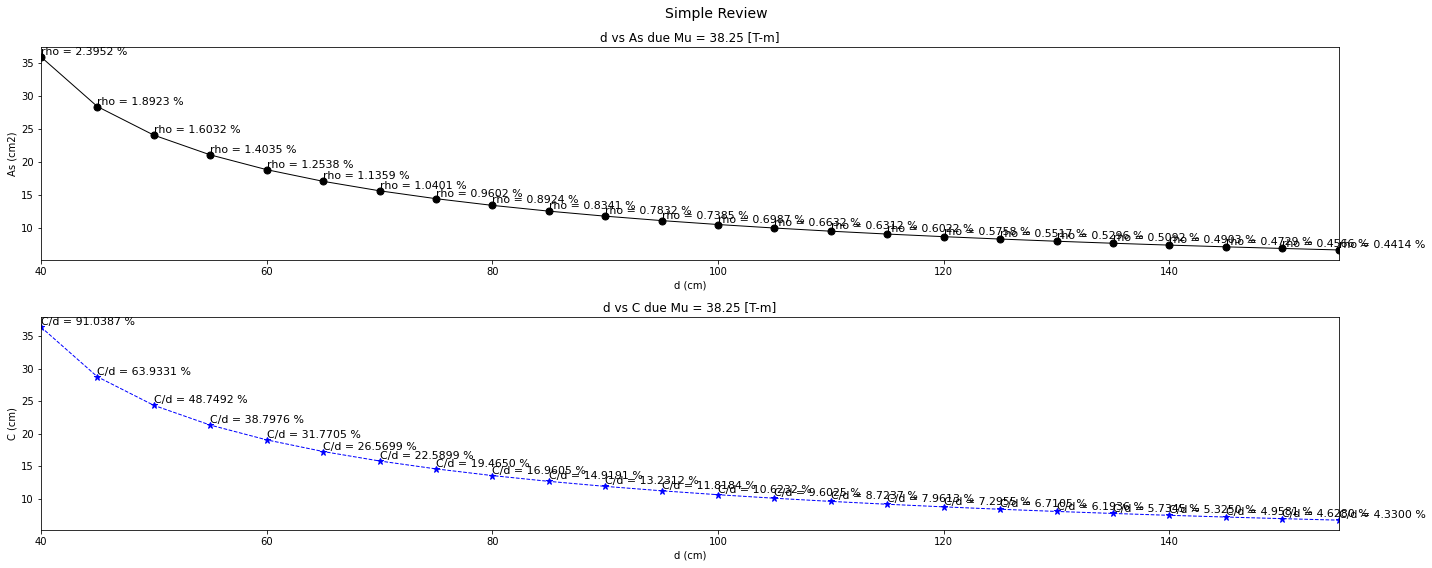

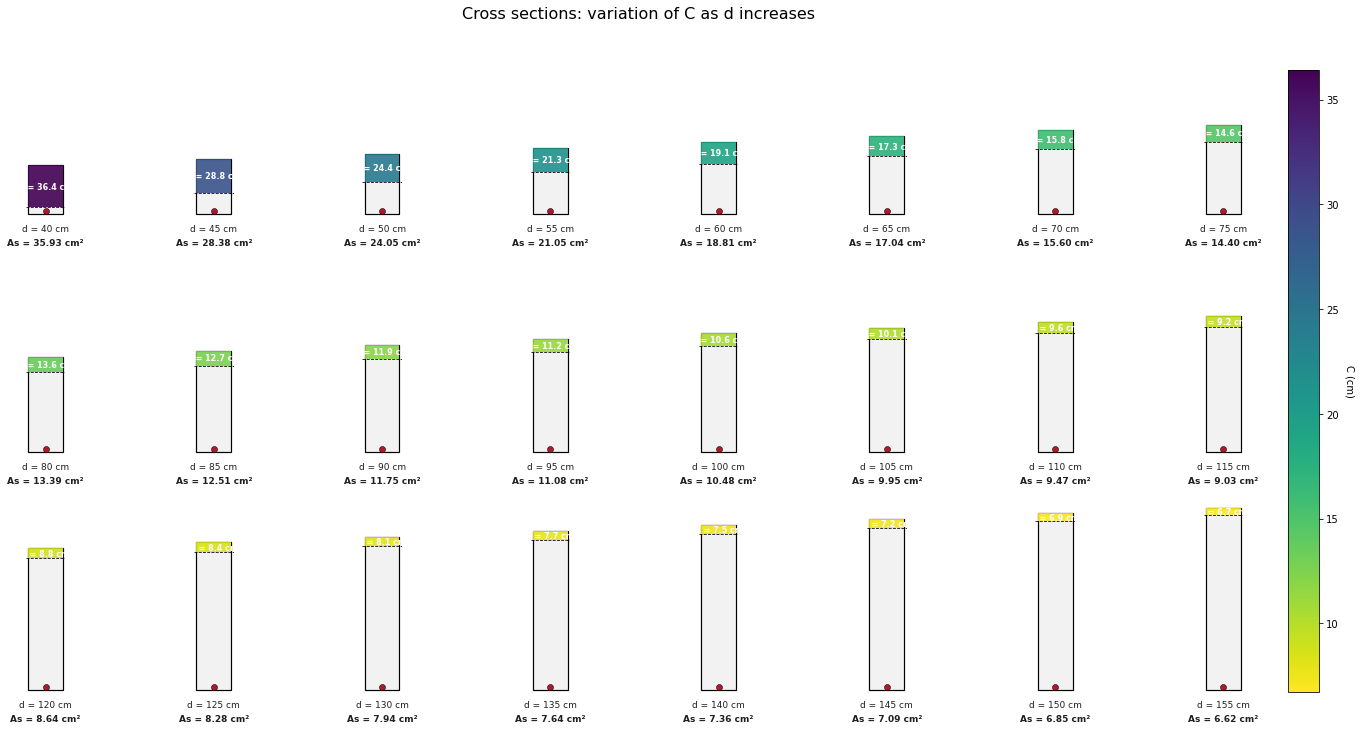

In [2]:
As = []                                                            # Initialize required-steel-area values
dd = []                                                            # Initialize effective-depth values
C = []                                                             # Initialize compression-block-depth values
ro = []                                                            # Initialize reinforcement-ratio values
Cd = []                                                            # Initialize C-to-d ratio values
d_start = 40
d_end = 160
d_step = 5

i = 0                                                              # Initialize the depth-case counter
for d in np.arange(d_start,d_end,d_step):                          # Evaluate effective depths from 40 to 145 cm
    As.append(0.85 * fc * b / fy * (d - np.sqrt(d**(2) - (2*Mu / fiM)/(0.85*fc*b))))  # Store required steel area
    dd.append(d)                                                    # Store the current effective depth
    C.append((fy*As[i]) / (Beta*0.85*fc*b))                         # Store the compression-block depth
    ro.append( As[i]/ (b*h))                                       # Store the reinforcement ratio
    Cd.append(C[i] / d)                                             # Store the normalized compression depth
    i += 1                                                          # Advance to the next depth case

fig, ax = plt.subplots(2,1,figsize = (20,8))                       # Create the two-panel parametric review
fig.suptitle("Simple Review", fontsize=14, y=0.98)              # Add the figure title

ax[0].plot(dd, As, ls = '-', lw = 1, marker = 'o', markersize = 7, color = (0,0,0), label = 'd vs As')  # Plot steel area versus depth

for d_i, As_i, ro_i in zip(dd, As, ro):                            # Visit each steel-area result
    ax[0].text(d_i, As_i, f'rho = {ro_i * 100:.4f} %',ha='left', va='bottom', fontsize = 11)  # Label its reinforcement ratio

ax[0].set_title(f'd vs As due Mu = {Mu / 1e5:.2f} [T-m]')          # Set the steel-area plot title
ax[0].set_xlabel('d (cm)')                                        # Label the effective-depth axis
ax[0].set_ylabel('As (cm2)')                                      # Label the steel-area axis
ax[0].set_xlim(np.min(dd), np.max(dd))                             # Set horizontal limits from the data

ax[1].plot(dd, C, ls = '--', lw = 1, marker = '*', markersize = 7, color = (0,0,1), label = 'd vs C')  # Plot compression depth versus depth
for d_i, C_i, Cd_i in zip(dd, C, Cd):                              # Visit each compression-depth result
    ax[1].text(d_i, C_i, f'C/d = {Cd_i * 100:.4f} %',ha='left', va='bottom', fontsize = 11)  # Label its normalized depth

ax[1].set_title(f'd vs C due Mu = {Mu / 1e5:.2f} [T-m]')           # Set the compression-depth plot title
ax[1].set_xlabel('d (cm)')                                        # Label the effective-depth axis
ax[1].set_ylabel('C (cm)')                                        # Label the compression-depth axis
ax[1].set_xlim(np.min(dd), np.max(dd))                             # Set horizontal limits from the data

plt.tight_layout()                                                 # Adjust spacing in the parametric review


######################################################################################################################
######################################################################################################################
######################################################################################################################
ncols = 8                                                          # Set the number of cross sections per row
nrows = int(np.ceil(len(dd) / ncols))                              # Calculate the required number of rows
cmap = plt.get_cmap('viridis_r')                                   # Select the compression-depth color scale
norm = colors.Normalize(vmin=np.min(C), vmax=np.max(C))            # Normalize colors using the full C range

fig_section, axes = plt.subplots(nrows, ncols, figsize=(20, 3.4 * nrows), constrained_layout=True)  # Create the cross-section matrix
axes = np.atleast_1d(axes).ravel()                                 # Convert axes to a one-dimensional array
fig_section.suptitle('Cross sections: variation of C as d increases', fontsize=16)  # Add the cross-section figure title

for ax_i, d_i, C_i, As_i in zip(axes, dd, C, As):                  # Draw one section for each depth case
    h_i = d_i + rec                                                # Reconstruct total depth from effective depth
    block_color = cmap(norm(C_i))                                  # Map the compression depth to a color

    ax_i.add_patch(patches.Rectangle((0, 0), b, h_i, facecolor='#f2f2f2', edgecolor='black', linewidth=1.2))  # Draw the concrete section
    ax_i.add_patch(patches.Rectangle((0, h_i - C_i), b, C_i, facecolor=block_color, edgecolor='none', alpha=0.90))  # Draw the compression block

    ax_i.plot(b / 2, h_i - d_i, 'o', ms=6, color='#b2182b', markeredgecolor='black', markeredgewidth=0.5)  # Draw tension steel at depth d
    ax_i.axhline(h_i - C_i, color='black', linewidth=0.8, linestyle='--')  # Draw the compression-block boundary
    ax_i.text(b / 2, h_i - C_i / 2, f'C = {C_i:.1f} cm', ha='center', va='center', fontsize=8, color='white', fontweight='bold')  # Label compression depth
    ax_i.annotate(f'd = {d_i:.0f} cm', xy=(b / 2, 0), xytext=(0, -10), textcoords='offset points', ha='center', va='top', fontsize=9, color='#202020', annotation_clip=False, clip_on=False, zorder=10)  # Label effective depth
    ax_i.annotate(f'As = {As_i:.2f} cm²', xy=(b / 2, 0), xytext=(0, -24), textcoords='offset points', ha='center', va='top', fontsize=9, color='#202020', fontweight='bold', annotation_clip=False, clip_on=False, zorder=10)  # Label required steel area

    ax_i.set_xlim(-2, b + 2)                                       # Set horizontal section limits
    ax_i.set_ylim(-0.25 * max(dd), max(dd) + rec + 4)              # Reserve lower space for section labels
    ax_i.set_aspect('equal')                                       # Preserve section geometry
    ax_i.axis('off')                                                # Hide subplot axes

for ax_i in axes[len(dd):]:                                        # Visit unused subplot positions
    ax_i.set_visible(False)                                        # Hide unused subplot positions


colorbar = fig_section.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes[:len(dd)], shrink=0.88, pad=0.02)  # Add the common C color scale
colorbar.set_label('C (cm)', rotation=270, labelpad=16)            # Label the color scale

## General Beams

General sections may have several tension and compression layers, irregular geometry, or a compression zone that cannot be reduced to one simple rectangle. The governing method remains compatibility plus equilibrium: for a trial $c$, obtain $\varepsilon_i=0.003(d_i-c)/c$ at every layer, use the corresponding material stresses, sum axial forces, iterate until $R(c)=0$, and calculate the moment from the resulting force system. For a discrete set of reinforcement layers, $N=\sum_iA_{s,i}f_{s,i}+C_c$ and $M=\sum_iA_{s,i}f_{s,i}(d_{ref}-d_i)+C_c(d_{ref}-y_C)$. The reference axis is arbitrary provided force equilibrium is satisfied and all lever arms are measured consistently.


In [3]:
from repo__CORE_concreteII_desing import *

In [4]:
# ----- Input data -----
bf = 50                                                          # Flange width [cm]
tf = 10                                                          # Flange thickness [cm]
h = 60                                                           # Total section depth [cm]
bw = 30                                                          # Web width [cm]

fc = 210                                                         # Concrete compressive strength [kg/cm2]
fy = 4200                                                        # Steel yield strength [kg/cm2]
beta = 0.85                                                      # Equivalent stress-block factor

num_capas = 3                                                    # Number of reinforcement layers
d_capas = np.array([5,20,45])                                    # Layer depths measured from the top face [cm]
diam_capas = np.array([1.6,1.6,3.2])                             # Bar diameters by layer [cm]
var_capas = np.array([3,2,6])                                    # Number of bars by layer

ec = 0.004                                                       # Extreme concrete compressive strain
C = 10                                                           # Assumed neutral-axis depth measured from the top face [cm]

steel = np.array([                                               # Idealized GR50 steel stress-strain relationship [kg/cm2, strain]
                [-4200, -0.014],
                [-4200, -0.0021],
                [0,0],
                [4200, 0.0021],
                [4200, 0.014]
])


In [5]:
# ----- Section properties -----
ag_ala = tf*bf                                                   # Calculate the flange area [cm2]
ag_alma = (h-tf)*bw                                              # Calculate the web area below the flange [cm2]
ag = ag_ala + ag_alma                                            # Calculate the gross section area [cm2]

areas = np.array([                                               # Define compression-block depth versus compression area
                    [0, 0],
                    [tf, ag_ala],
                    [h, ag_ala + ag_alma]
])


x_cgc = []                                                       # Initialize compression-area centroid values [cm]
aa = []                                                          # Initialize equivalent compression-block depths [cm]
for a in np.arange(tf, h + 5, 5):                                # Evaluate centroid locations for successive block depths
    x_cgc.append((ag_ala*tf/2 + ((a-tf)*bw*(tf+(a-tf)/2))) / (bf*tf + (a-tf)*bw))  # Store the compression-area centroid
    aa.append(a)                                                 # Store the current compression-block depth

aa = [0,*aa]                                                     # Include the zero-depth reference point
x_cgc = [0,*x_cgc]                                               # Include the zero-centroid reference point
x_cgc_df = pd.DataFrame(x_cgc, columns=['x_cgc [cm]'])           # Store centroid values in a table
aa_df = pd.DataFrame(aa, columns=['a [cm]'])                      # Store block-depth values in a table

print('='*120)                                                   # Print the report separator
print(f'Flange area = {ag_ala:.2f} cm2 + web area = {ag_alma:.2f} cm2 = gross area = {ag:.2f} cm2')  # Print section areas

Flange area = 500.00 cm2 + web area = 1500.00 cm2 = gross area = 2000.00 cm2


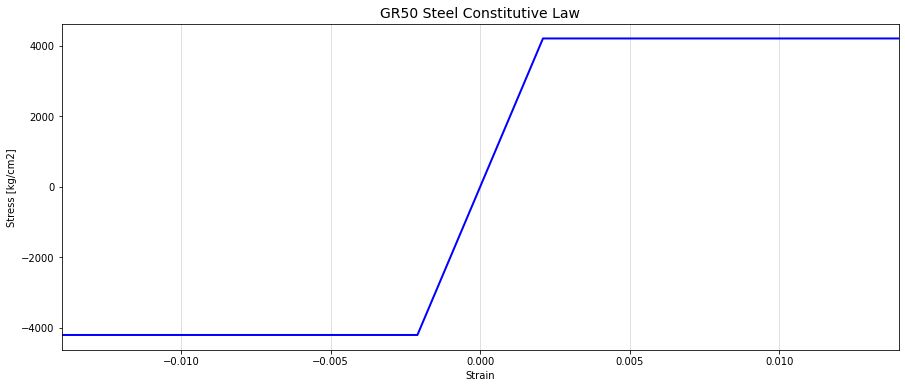

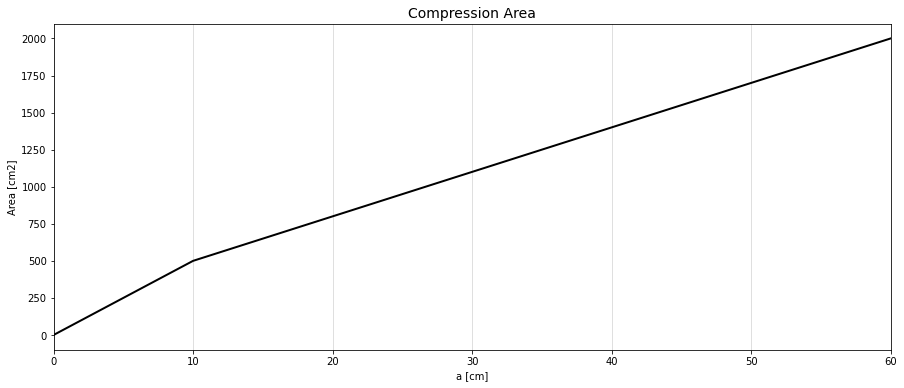

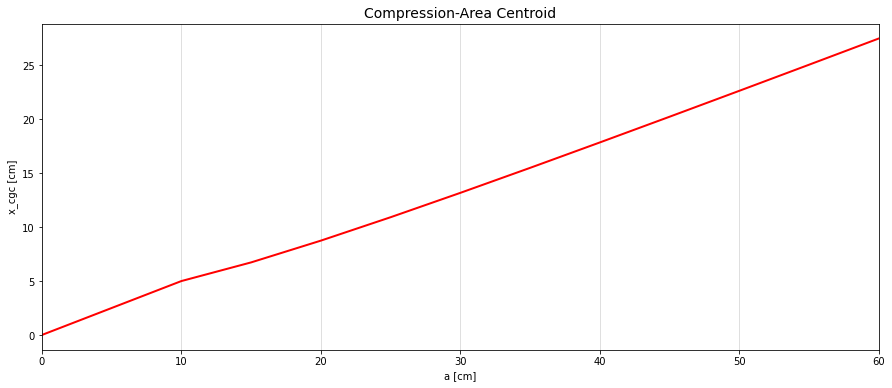

In [6]:
# ----- Material and section-property plots -----
plotsteel = SimpleClass(steel[:,1], steel[:,0], title='GR50 Steel Constitutive Law', xlabel='Strain', ylabel='Stress [kg/cm2]', color=(0,0,1))  # Create the steel stress-strain plot
plotsteel.SimplePlot()                                            # Display the steel constitutive law

plot_area_a = SimpleClass(areas[:,0], areas[:,1], title='Compression Area', xlabel='a [cm]', ylabel='Area [cm2]',
                          color=(0,0,0))                          # Create the compression-area plot
plot_area_a.SimplePlot()                                         # Display compression area versus block depth

plot_x_cgc = SimpleClass(aa, x_cgc, title='Compression-Area Centroid', xlabel='a [cm]', ylabel='x_cgc [cm]',
                          color=(1,0,0))                          # Create the centroid-location plot
plot_x_cgc.SimplePlot()                                          # Display centroid location versus block depth

In [7]:
as_capas = []                                                    # Initialize steel areas by layer [cm2]
es_capas = []                                                    # Initialize steel strains by layer
fs_capas = []                                                    # Initialize steel stresses by layer [kg/cm2]
Fs_capas = []                                                    # Initialize steel forces by layer [kg]
Ms_capas = []                                                    # Initialize steel moments by layer [kg-cm]
as_fy_d = []                                                     # Initialize yield-force moments used for the plastic centroid [kg-cm]
as_fy = []                                                       # Initialize yield forces used for the plastic centroid [kg]

for i in np.arange(0, len(d_capas), 1):                          # Evaluate each reinforcement layer
    as_capas.append(var_capas[i] * 1/4 * np.pi*diam_capas[i]**2) # Calculate the total steel area in the layer
    es_capas.append((ec*(d_capas[i] - C))/C * -1)                # Calculate steel strain from section compatibility
    fs_capas.append(np.interp(es_capas[i],steel[:,1],steel[:,0]))  # Interpolate steel stress from the constitutive law
    Fs_capas.append(fs_capas[i]*as_capas[i])                      # Calculate the resultant steel force
    Ms_capas.append(Fs_capas[i] * d_capas[i] * -1)               # Calculate the steel moment about the top face
    as_fy_d.append(as_capas[i]*fy*d_capas[i])                    # Store the yield-force moment for the plastic centroid
    as_fy.append(as_capas[i]*fy)                                 # Store the yield force for the plastic centroid

ac = beta * C                                                    # Calculate the equivalent compression-block depth [cm]
area_ac = np.interp(ac,areas[:,0], areas[:,1])                   # Interpolate the compression-block area [cm2]
fc_ac = 0.85*fc                                                  # Calculate the equivalent concrete compressive stress [kg/cm2]
Fc_ac = fc_ac * area_ac                                          # Calculate the concrete compression resultant [kg]

if ac <= tf:                                                     # Locate the compression resultant within the flange
    x_ac = ac / 2                                                # Use the rectangular-block centroid
else:
    x_ac = (ag_ala*tf/2 + ((ac-tf)*bw*(tf+(ac-tf)/2))) / (bf*tf + (ac-tf)*bw)  # Use the T-section compression-area centroid

Mc_ac = Fc_ac * x_ac * -1                                       # Calculate the concrete compression moment about the top face [kg-cm]

x_cgf = (ag_ala*tf/2 + (h-tf)*bw*((h-tf)/2+tf)) / (ag_ala + (h-tf)*bw)  # Calculate the gross-section centroid [cm]

xcp = ((ag*0.85*fc*x_cgf) + np.sum(as_fy_d)) / (0.85*fc*ag + np.sum(as_fy))  # Calculate the plastic centroid [cm]

In [8]:
# ----- Reinforcement-layer summary -----

diam_capas_df = pd.DataFrame(diam_capas * 10, columns=['Bar diameter (mm)'])  # Store bar diameters by layer
var_capas_df = pd.DataFrame(var_capas, columns=['Number of bars'])            # Store bar counts by layer
d_capas_df = pd.DataFrame(d_capas, columns=['d (cm)'])                        # Store layer depths
as_capas_df = pd.DataFrame(as_capas, columns=['As per layer (cm2)'])          # Store steel areas
es_capas_df = pd.DataFrame(es_capas, columns=['Steel strain'])                 # Store steel strains
fs_capas_df = pd.DataFrame(fs_capas, columns=['Steel stress per layer (kg/cm2)'])  # Store steel stresses
Fs_capas_df = pd.DataFrame(Fs_capas, columns=['Steel force per layer (kg)'])   # Store steel forces
Ms_capas_df = pd.DataFrame(Ms_capas, columns=['Steel moment per layer (kg-cm)'])  # Store steel moments

Resul_df = pd.concat([diam_capas_df, var_capas_df, d_capas_df, as_capas_df, es_capas_df, fs_capas_df,
                      Fs_capas_df, Ms_capas_df], axis=1)                       # Combine layer quantities into one table

Resul_df.head()                                                   # Display the layer summary

,Bar diameter (mm),Number of bars,d (cm),As per layer (cm2),Steel strain,Steel stress per layer (kg/cm2),Steel force per layer (kg),Steel moment per layer (kg-cm)
0,16.0,3,5,6.031858,0.002,4000.0,24127.431580,-1.206372e+05
1,16.0,2,20,4.021239,-0.004,-4200.0,-16889.202106,3.377840e+05
2,32.0,6,45,48.254863,-0.014,-4200.0,-202670.425268,9.120169e+06


In [9]:
# ----- Section resultants -----

Fs_total = np.sum(Fs_capas)                                      # Sum steel forces [kg]
Fc_total = Fc_ac                                                  # Assign the concrete compression resultant [kg]

P = Fs_total + Fc_total                                           # Calculate the section axial-force resultant [kg]
M = Mc_ac + np.sum(Ms_capas) - P*xcp                              # Calculate the moment resultant about the plastic centroid [kg-cm]

print('='*120)                                                   # Print the report separator
print(f'Assumed neutral-axis depth, c = {C:.2f} cm')              # Print the assumed neutral-axis depth
print(f'Geometric centroid = {x_cgf:.2f} cm')                     # Print the gross-section centroid
print(f'Plastic centroid = {xcp:.2f} cm')                         # Print the plastic centroid
print(f'Resultant axial force = {P / 1000:.2f} T')                # Print the section axial-force resultant
print(f'Moment resultant = {M / 1e5:.2f} T-m')                    # Print the moment resultant
print('='*120)                                                    # Close the report separator

Assumed neutral-axis depth, c = 10.00 cm
Geometric centroid = 27.50 cm
Plastic centroid = 32.24 cm
Resultant axial force = -119.57 T
Moment resultant = 128.69 T-m
